<a href="https://colab.research.google.com/github/akira0771/project-c-main/blob/main/RS2%E5%AE%9F%E9%A8%93%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ver1.単精度倍精度切り替えのみ

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 0. パラメータ設定
# ==========================================
class Config:
    # --- 共通物理パラメータ ---
    U0 = 0.85
    TAU = 1.0

    # --- ケース設定 (Middle Case) ---
    # label: Middle
    # u1: 0.935 (中段)
    # mode: "robust" (衝撃波解)
    CASES = [
        {"label": "Middle", "u1": 0.935,  "mode": "robust", "z2_fixed": 0.15},
    ]

    # --- 計算領域の設定 ---
    DOMAIN_WIDE = 2.0   # 全体の広さ [-2.0, 2.0]

    # --- 学習ハイパーパラメータ ---
    ADAM_EPOCHS = 16000  # 収束まで十分回す
    LR = 1e-3           # 学習率

    # --- 精度設定 (単精度: torch.float32, 倍精度: torch.float64) ---
    DTYPE = torch.float64

    # --- 損失関数の重み ---
    W_PHYS = 1.0      # 方程式の残差
    W_BC   = 1.0     # 境界条件
    W_RH   = 1.0    # 接続条件 (Flux連続性)

    # --- 描画設定 ---
    PLOT_X_RANGE = (-1.5, 1.5)

    # 色設定 [Left, Right]
    ROBUST_COLORS = ['tab:blue', 'tab:orange']

    # 固定する衝撃波位置
    Z1_FIXED = 0.0

# ==========================================
# 1. 物理式計算
# ==========================================
def compute_s(u0, u1):
    term1 = (u1**2 + u0*u1 + u0**2) / 6.0
    term2 = (u1**4 + u0*(u1**3) + (u0**2)*(u1**2) +
             (u0**3)*u1 + u0**4) / 10.0
    return term1 + term2

def compute_C(u_val, s_val):
    return -2.0 * s_val * u_val + (u_val**3 / 3.0 + u_val**5 / 5.0)

def get_integral(u, v, s_val):
    integral = -s_val * (u + v) + (u**3 / 3.0 + v**5 / 5.0)
    return integral

def get_RHsub(u, v, s_val):
    flux1 = u
    flux2 = -s_val * v + (v**5 / 5.0)
    return flux1, flux2

# ==========================================
# 2. モデル定義
# ==========================================
class PINN(nn.Module):
    def __init__(self, input_scale=1.0, out_init=(0.85, 0.85)):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 60), nn.Tanh(),
            nn.Linear(60, 60), nn.Tanh(),
            nn.Linear(60, 60), nn.Tanh(),
            nn.Linear(60, 60), nn.Tanh(),
            nn.Linear(60, 2)
        )
        self.net.to(Config.DTYPE)
        nn.init.constant_(self.net[-1].bias[0], out_init[0])
        nn.init.constant_(self.net[-1].bias[1], out_init[1])
        nn.init.xavier_normal_(self.net[-1].weight, gain=0.01)
        self.input_scale = input_scale

    def forward(self, z):
        return self.net(z * self.input_scale)

class ShockPosition(nn.Module):
    def __init__(self, z1_init):
        super().__init__()
        self.z_s1 = nn.Parameter(torch.tensor(float(z1_init), dtype=Config.DTYPE))

# ==========================================
# 3. 学習プロセス
# ==========================================
def solve_case(case_setting):
    u1 = case_setting["u1"]
    mode = case_setting["mode"]
    label = case_setting["label"]

    print(f"\n>>> Solving {label} Case (u1={u1}, Fixed z1={Config.Z1_FIXED}) <<<")

    # ==========================================
    # 物理損失計算 (残差計算)
    # ==========================================
    def compute_residual_loss(model, z, s_val, C_val, tau_val):
        if z.numel() == 0:
            return torch.tensor(0.0).to(z.device)

        z = z.clone().detach().requires_grad_(True)
        out = model(z)
        u, v = out[:, 0:1], out[:, 1:2]

        u_z = torch.autograd.grad(u, z, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        res_ode = (-s_val + u**2) * u_z - (v - u) / tau_val
        integral = get_integral(u, v, s_val)
        res_alg = integral - C_val

        return torch.mean(res_ode**2) + torch.mean(res_alg**2)

    # ==========================================
    # 準備
    # ==========================================
    s_target = compute_s(Config.U0, u1)
    C_target = compute_C(Config.U0, s_target)

    z_wide = torch.linspace(-Config.DOMAIN_WIDE, Config.DOMAIN_WIDE, 1000, dtype=Config.DTYPE)
    z_base = torch.cat([z_wide]).sort()[0].view(-1, 1)

    z_bc_L = torch.tensor([[-Config.DOMAIN_WIDE]], dtype=Config.DTYPE)
    z_bc_R = torch.tensor([[ Config.DOMAIN_WIDE]], dtype=Config.DTYPE)

    # ==========================================
    # モデル構築
    # ==========================================
    models = []

    if mode == "robust":
        # Left Model (z < z1)
        model_L = PINN(out_init=(u1, u1))
        models.append(model_L)

        # Middle Model (z > z1)
        u_mid_init = (u1 + Config.U0) / 2.0
        model_R = PINN(out_init=(u_mid_init, u_mid_init))
        models.append(model_R)

        z1_init = 0.0
        shock_pos = ShockPosition(z1_init=z1_init)

        params = list(model_L.parameters()) + list(model_R.parameters()) + [shock_pos.z_s1]

    # ==========================================
    # 損失関数
    # ==========================================
    def compute_total_loss():
        # --- Robust Loss ---
        z1_val = float(shock_pos.z_s1)

        # 領域分割 (z1のみで左右に分割)
        mask_L = z_base[:, 0] < z1_val
        mask_R = z_base[:, 0] >= z1_val

        # 1. 物理損失
        loss_physics_L = compute_residual_loss(models[0], z_base[mask_L], s_target, C_target, Config.TAU)
        loss_physics_R = compute_residual_loss(models[1], z_base[mask_R], s_target, C_target, Config.TAU)
        loss_physics = loss_physics_L + loss_physics_R

        # 2. 境界損失 (左端のみ)
        u_bc_L = models[0](z_bc_L)[:, 0]
        u_bc_R = models[1](z_bc_R)[:, 0]
        loss_boundary = ((u_bc_L - u1)**2).sum() + ((u_bc_R - Config.U0)**2).sum()

        # 3. 接続損失 (Rankine-Hugoniot at z1)
        z_j1 = shock_pos.z_s1.view(1, 1)
        outL = models[0](z_j1) # Leftモデルの右端
        outR = models[1](z_j1) # Rightモデルの左端

        FL1, FL2 = get_RHsub(outL[:,0], outL[:,1], s_target)
        FR1, FR2 = get_RHsub(outR[:,0], outR[:,1], s_target)

        loss_rh = torch.mean((FL1-FR1)**2 + (FL2-FR2)**2)

        return Config.W_PHYS * loss_physics + \
               Config.W_BC   * loss_boundary + \
               Config.W_RH   * loss_rh

    # ==========================================
    # 最適化
    # ==========================================
    import time

    optimizer_adam = optim.Adam(params, lr=Config.LR)
    print("Starting Adam...")
    min_loss = 1
    start_time = time.time()

    for ep in range(Config.ADAM_EPOCHS):
        optimizer_adam.zero_grad()
        loss = compute_total_loss()
        if ep > Config.ADAM_EPOCHS*0.8 and loss < min_loss:
            z1_val = float(shock_pos.z_s1)
            elapsed_time = time.time() - start_time
            print(f"Adam Ep {ep}: Loss {loss.item():.10f} | z1={z1_val:.6f} | Time: {elapsed_time:.2f}s")
            break
        if loss < min_loss:
            min_loss = loss
        loss.backward()
        optimizer_adam.step()

        if ep % 1000 == 0:
            z1_val = float(shock_pos.z_s1)
            elapsed_time = time.time() - start_time
            print(f"Adam Ep {ep}: Loss {loss.item():.10f} | z1={z1_val:.4f} | Time: {elapsed_time:.2f}s")

    # ==========================================
    # 結果整形
    # ==========================================
    z_plot = torch.linspace(-3.5, 3.5, 1000, dtype=Config.DTYPE).view(-1, 1)
    z_np = z_plot.numpy().flatten()

    with torch.no_grad():
        pL = models[0](z_plot).numpy()
        pR = models[1](z_plot).numpy()

        # マスキング
        pL[z_np > z1_val] = np.nan
        pR[z_np < z1_val] = np.nan

        u_list = [pL[:, 0], pR[:, 0]]
        v_list = [pL[:, 1], pR[:, 1]]
        shock_locs = [z1_val]

    return z_np, u_list, v_list, shock_locs

# ==========================================
# 4. メイン実行 & 保存
# ==========================================
if __name__ == "__main__":
    results = []
    for case in Config.CASES:
        res = solve_case(case)
        results.append(res)

    # 計算結果を保存
    torch.save(results, "region_II.pt")
    print("Results saved.pt")


>>> Solving Middle Case (u1=0.935, Fixed z1=0.0) <<<
Starting Adam...
Adam Ep 0: Loss 0.0035648755 | z1=-0.0010 | Time: 0.05s
Adam Ep 1000: Loss 0.0000027850 | z1=0.0001 | Time: 18.67s
Adam Ep 2000: Loss 0.0000012170 | z1=-0.0078 | Time: 37.65s
Adam Ep 3000: Loss 0.0000009797 | z1=-0.0361 | Time: 55.77s
Adam Ep 4000: Loss 0.0000019397 | z1=-0.0471 | Time: 74.86s
Adam Ep 5000: Loss 0.0000002151 | z1=-0.0480 | Time: 92.84s
Adam Ep 6000: Loss 0.0000001257 | z1=-0.0512 | Time: 111.99s
Adam Ep 7000: Loss 0.0000000761 | z1=-0.0522 | Time: 130.15s
Adam Ep 8000: Loss 0.0000000795 | z1=-0.0544 | Time: 148.09s
Adam Ep 9000: Loss 0.0000001883 | z1=-0.0546 | Time: 167.31s
Adam Ep 10000: Loss 0.0000000640 | z1=-0.0544 | Time: 185.41s
Adam Ep 11000: Loss 0.0000000477 | z1=-0.0562 | Time: 204.70s
Adam Ep 12000: Loss 0.0000000374 | z1=-0.0579 | Time: 222.81s
Adam Ep 12801: Loss 0.0000000344 | z1=-0.059793 | Time: 237.29s
Results saved.pt


ver2.単倍精度と活性化関数切り替え

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 0. パラメータ設定
# ==========================================
class Config:
    # --- 共通物理パラメータ ---
    U0 = 0.85
    TAU = 1.0

    # --- ケース設定 (Middle Case) ---
    # label: Middle
    # u1: 0.935 (中段)
    # mode: "robust" (衝撃波解)
    CASES = [
        {"label": "Middle", "u1": 0.935,  "mode": "robust", "z2_fixed": 0.15},
    ]

    # --- 計算領域の設定 ---
    DOMAIN_WIDE = 2.0   # 全体の広さ [-2.0, 2.0]

    # --- 学習ハイパーパラメータ ---
    ADAM_EPOCHS = 16000  # 収束まで十分回す
    LR = 1e-3           # 学習率

    # --- 精度設定 (単精度: torch.float32, 倍精度: torch.float64) ---
    DTYPE = torch.float32

    # --- 活性化関数の設定 (例: nn.Tanh, nn.ReLU, nn.GELU など) ---
    ACT_FUNC = nn.Tanh

    # --- 損失関数の重み ---
    W_PHYS = 1.0      # 方程式の残差
    W_BC   = 1.0     # 境界条件
    W_RH   = 1.0    # 接続条件 (Flux連続性)

    # --- 描画設定 ---
    PLOT_X_RANGE = (-1.5, 1.5)

    # 色設定 [Left, Right]
    ROBUST_COLORS = ['tab:blue', 'tab:orange']

    # 固定する衝撃波位置
    Z1_FIXED = 0.0

# ==========================================
# 1. 物理式計算
# ==========================================
def compute_s(u0, u1):
    term1 = (u1**2 + u0*u1 + u0**2) / 6.0
    term2 = (u1**4 + u0*(u1**3) + (u0**2)*(u1**2) +
             (u0**3)*u1 + u0**4) / 10.0
    return term1 + term2

def compute_C(u_val, s_val):
    return -2.0 * s_val * u_val + (u_val**3 / 3.0 + u_val**5 / 5.0)

def get_integral(u, v, s_val):
    integral = -s_val * (u + v) + (u**3 / 3.0 + v**5 / 5.0)
    return integral

def get_RHsub(u, v, s_val):
    flux1 = u
    flux2 = -s_val * v + (v**5 / 5.0)
    return flux1, flux2

# ==========================================
# 2. モデル定義
# ==========================================
class PINN(nn.Module):
    def __init__(self, input_scale=1.0, out_init=(0.85, 0.85)):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 60), Config.ACT_FUNC(),
            nn.Linear(60, 60), Config.ACT_FUNC(),
            nn.Linear(60, 60), Config.ACT_FUNC(),
            nn.Linear(60, 60), Config.ACT_FUNC(),
            nn.Linear(60, 2)
        )
        self.net.to(Config.DTYPE)
        nn.init.constant_(self.net[-1].bias[0], out_init[0])
        nn.init.constant_(self.net[-1].bias[1], out_init[1])
        nn.init.xavier_normal_(self.net[-1].weight, gain=0.01)
        self.input_scale = input_scale

    def forward(self, z):
        return self.net(z * self.input_scale)

class ShockPosition(nn.Module):
    def __init__(self, z1_init):
        super().__init__()
        self.z_s1 = nn.Parameter(torch.tensor(float(z1_init), dtype=Config.DTYPE))

# ==========================================
# 3. 学習プロセス
# ==========================================
def solve_case(case_setting):
    u1 = case_setting["u1"]
    mode = case_setting["mode"]
    label = case_setting["label"]

    print(f"\n>>> Solving {label} Case (u1={u1}, Fixed z1={Config.Z1_FIXED}) <<<")

    # ==========================================
    # 物理損失計算 (残差計算)
    # ==========================================
    def compute_residual_loss(model, z, s_val, C_val, tau_val):
        if z.numel() == 0:
            return torch.tensor(0.0).to(z.device)

        z = z.clone().detach().requires_grad_(True)
        out = model(z)
        u, v = out[:, 0:1], out[:, 1:2]

        u_z = torch.autograd.grad(u, z, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        res_ode = (-s_val + u**2) * u_z - (v - u) / tau_val
        integral = get_integral(u, v, s_val)
        res_alg = integral - C_val

        return torch.mean(res_ode**2) + torch.mean(res_alg**2)

    # ==========================================
    # 準備
    # ==========================================
    s_target = compute_s(Config.U0, u1)
    C_target = compute_C(Config.U0, s_target)

    z_wide = torch.linspace(-Config.DOMAIN_WIDE, Config.DOMAIN_WIDE, 1000, dtype=Config.DTYPE)
    z_base = torch.cat([z_wide]).sort()[0].view(-1, 1)

    z_bc_L = torch.tensor([[-Config.DOMAIN_WIDE]], dtype=Config.DTYPE)
    z_bc_R = torch.tensor([[ Config.DOMAIN_WIDE]], dtype=Config.DTYPE)

    # ==========================================
    # モデル構築
    # ==========================================
    models = []

    if mode == "robust":
        # Left Model (z < z1)
        model_L = PINN(out_init=(u1, u1))
        models.append(model_L)

        # Middle Model (z > z1)
        u_mid_init = (u1 + Config.U0) / 2.0
        model_R = PINN(out_init=(u_mid_init, u_mid_init))
        models.append(model_R)

        z1_init = 0.0
        shock_pos = ShockPosition(z1_init=z1_init)

        params = list(model_L.parameters()) + list(model_R.parameters()) + [shock_pos.z_s1]

    # ==========================================
    # 損失関数
    # ==========================================
    def compute_total_loss():
        # --- Robust Loss ---
        z1_val = float(shock_pos.z_s1)

        # 領域分割 (z1のみで左右に分割)
        mask_L = z_base[:, 0] < z1_val
        mask_R = z_base[:, 0] >= z1_val

        # 1. 物理損失
        loss_physics_L = compute_residual_loss(models[0], z_base[mask_L], s_target, C_target, Config.TAU)
        loss_physics_R = compute_residual_loss(models[1], z_base[mask_R], s_target, C_target, Config.TAU)
        loss_physics = loss_physics_L + loss_physics_R

        # 2. 境界損失 (左端のみ)
        u_bc_L = models[0](z_bc_L)[:, 0]
        u_bc_R = models[1](z_bc_R)[:, 0]
        loss_boundary = ((u_bc_L - u1)**2).sum() + ((u_bc_R - Config.U0)**2).sum()

        # 3. 接続損失 (Rankine-Hugoniot at z1)
        z_j1 = shock_pos.z_s1.view(1, 1)
        outL = models[0](z_j1) # Leftモデルの右端
        outR = models[1](z_j1) # Rightモデルの左端

        FL1, FL2 = get_RHsub(outL[:,0], outL[:,1], s_target)
        FR1, FR2 = get_RHsub(outR[:,0], outR[:,1], s_target)

        loss_rh = torch.mean((FL1-FR1)**2 + (FL2-FR2)**2)

        return Config.W_PHYS * loss_physics + \
               Config.W_BC   * loss_boundary + \
               Config.W_RH   * loss_rh

    # ==========================================
    # 最適化
    # ==========================================
    import time

    optimizer_adam = optim.Adam(params, lr=Config.LR)
    print("Starting Adam...")
    min_loss = 1
    start_time = time.time()

    for ep in range(Config.ADAM_EPOCHS):
        optimizer_adam.zero_grad()
        loss = compute_total_loss()
        if ep > Config.ADAM_EPOCHS*0.8 and loss < min_loss:
            z1_val = float(shock_pos.z_s1)
            elapsed_time = time.time() - start_time
            print(f"Adam Ep {ep}: Loss {loss.item():.10f} | z1={z1_val:.6f} | Time: {elapsed_time:.2f}s")
            break
        if loss < min_loss:
            min_loss = loss
        loss.backward()
        optimizer_adam.step()

        if ep % 1000 == 0:
            z1_val = float(shock_pos.z_s1)
            elapsed_time = time.time() - start_time
            print(f"Adam Ep {ep}: Loss {loss.item():.10f} | z1={z1_val:.4f} | Time: {elapsed_time:.2f}s")

    # ==========================================
    # 結果整形
    # ==========================================
    z_plot = torch.linspace(-3.5, 3.5, 1000, dtype=Config.DTYPE).view(-1, 1)
    z_np = z_plot.numpy().flatten()

    with torch.no_grad():
        pL = models[0](z_plot).numpy()
        pR = models[1](z_plot).numpy()

        # マスキング
        pL[z_np > z1_val] = np.nan
        pR[z_np < z1_val] = np.nan

        u_list = [pL[:, 0], pR[:, 0]]
        v_list = [pL[:, 1], pR[:, 1]]
        shock_locs = [z1_val]

    return z_np, u_list, v_list, shock_locs

# ==========================================
# 4. メイン実行 & 保存
# ==========================================
if __name__ == "__main__":
    results = []
    for case in Config.CASES:
        res = solve_case(case)
        results.append(res)

    # 計算結果を保存
    torch.save(results, "region_II.pt")
    print("Results saved.pt")


>>> Solving Middle Case (u1=0.935, Fixed z1=0.0) <<<
Starting Adam...
Adam Ep 0: Loss 0.0037720278 | z1=0.0010 | Time: 0.02s
Adam Ep 1000: Loss 0.0000036938 | z1=-0.0184 | Time: 15.30s
Adam Ep 2000: Loss 0.0000024302 | z1=-0.0357 | Time: 30.55s
Adam Ep 3000: Loss 0.0000009955 | z1=-0.0392 | Time: 45.80s
Adam Ep 4000: Loss 0.0000003087 | z1=-0.0386 | Time: 60.93s
Adam Ep 5000: Loss 0.0000001747 | z1=-0.0353 | Time: 76.74s
Adam Ep 6000: Loss 0.0000001205 | z1=-0.0313 | Time: 92.04s
Adam Ep 7000: Loss 0.0000001237 | z1=-0.0265 | Time: 107.32s
Adam Ep 8000: Loss 0.0000002744 | z1=-0.0223 | Time: 122.65s
Adam Ep 9000: Loss 0.0000004897 | z1=-0.0196 | Time: 137.87s
Adam Ep 10000: Loss 0.0000009964 | z1=-0.0146 | Time: 153.54s
Adam Ep 11000: Loss 0.0000001925 | z1=-0.0171 | Time: 169.22s
Adam Ep 12000: Loss 0.0000001342 | z1=-0.0216 | Time: 184.55s
Adam Ep 13000: Loss 0.0000001035 | z1=-0.0267 | Time: 199.90s
Adam Ep 14000: Loss 0.0000000904 | z1=-0.0284 | Time: 215.36s
Adam Ep 15000: Loss 0

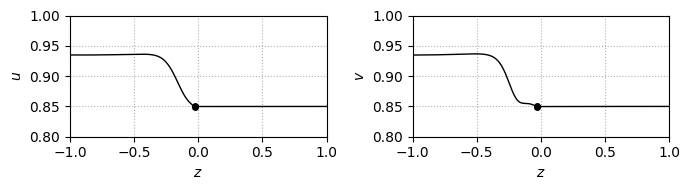

In [ ]:
# ==========================================
# 設定
# ==========================================
RESULTS_FILE = "region_II.pt"
PLOT_X_RANGE = (-1, 1)
COLORS = ['tab:blue', 'tab:orange'] # [Left, Right]

# ==========================================
# 描画処理
# ==========================================
if __name__ == "__main__":
    # データの読み込み
    try:
        results = torch.load(RESULTS_FILE, weights_only=False)
    except FileNotFoundError:
        print(f"File {RESULTS_FILE} not found. Please run the calculation code first.")
        results = None

    if results is not None:
        z, u_list, v_list, shocks = results[0]

        # データセット作成
        data_sets = [u_list, v_list]
        ylabels = [r'$u$', r'$v$']
        # uv_sum_list = [u + v for u, v in zip(u_list, v_list)]
        # data_sets = [u_list, v_list, uv_sum_list]
        # ylabels = [r'$u$', r'$v$', r'$u+v$']

        # グラフ作成
        fig, axes = plt.subplots(1, 2, figsize=(7, 2))
#        fig.suptitle(f"Results: Middle Case (z1 fixed)", fontsize=14)

        for k, ax in enumerate(axes):
            current_data = data_sets[k]

            # (a) 解のプロット
            for i, y_data in enumerate(current_data):
                color = 'k'
#                color = COLORS[i % 2]

                mask = ~np.isnan(y_data)
                z_valid = z[mask]
                y_valid = y_data[mask]

                if len(z_valid) > 0:
                    ax.plot(z_valid, y_valid, color=color, lw=1)

                    # 線をつなげる処理 (補完)
                    if shocks is not None:
                        shock_z = shocks[0]
                        # Leftモデル(i=0)は右へ伸ばす
                        if i == 0:
                            ax.plot([z_valid[-1], shock_z], [y_valid[-1], y_valid[-1]], color=color, lw=2)
                        # Rightモデル(i=1)は左へ伸ばす
                        elif i == 1:
                            ax.plot([shock_z, z_valid[0]], [y_valid[0], y_valid[0]], color=color, lw=2)

            # (b) 衝撃波位置の点線
            if shocks is not None:
                shock_z = shocks[0]
                # Leftの末尾値
                y_L_seg = current_data[0]
                val_L = y_L_seg[~np.isnan(y_L_seg)][-1]
                # Rightの先頭値
                y_R_seg = current_data[1]
                val_R = y_R_seg[~np.isnan(y_R_seg)][0]

                ax.plot([shock_z]*2, [val_L, val_R], 'k:', lw=1.5)
                ax.plot(shock_z, val_L, 'ko', ms=4)
                ax.plot(shock_z, val_R, 'ko', ms=4)

            # (c) 軸設定
            ax.set_xlim(PLOT_X_RANGE)
            if k==0: ax.set_ylim(0.8, 1.0)
            if k==1: ax.set_ylim(0.8, 1.0)
            if k==2: ax.set_ylim(1.6, 2.0)

            ax.set_ylabel(ylabels[k])
            ax.set_xlabel(r'$z$')
            ax.grid(ls=':')

        plt.tight_layout()
        plt.savefig('shock_structure_u0_0_85-u1_0.935.pdf')
        plt.show()